<a href="https://colab.research.google.com/github/newazkhn/FloodPINN/blob/main/notebooks/05_unet_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# FULL SESSION SETUP — Run this first every time
# ============================================================

# Install libraries
!pip install segmentation-models-pytorch -q
!pip install h5py -q

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import segmentation_models_pytorch as smp
import numpy as np
import h5py
import os
import gc
import random
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# Verify GPU
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu')
print("=" * 55)
print("  FloodPINN — Session Ready")
print("=" * 55)
print(f"\n  Device     : {device}")
if torch.cuda.is_available():
    print(f"  GPU        : "
          f"{torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory
    print(f"  GPU Memory : {mem/1e9:.1f} GB")
    print("  ✓ GPU ready!")
else:
    print("  ⚠ No GPU — Runtime → Change runtime type")

# Paths
DRIVE_BASE    = '/content/drive/MyDrive'
DATA_FOLDER   = f'{DRIVE_BASE}/FloodPINN_Chips'
OUTPUT_FOLDER = f'{DRIVE_BASE}/FloodPINN_Models'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Config
CONFIG = {
    'model_name'  : 'unet_baseline',
    'encoder'     : 'efficientnet-b0',
    'in_channels' : 8,
    'out_classes' : 1,
    'batch_size'  : 4,
    'epochs'      : 30,
    'lr'          : 1e-4,
    'weight_decay': 1e-5,
    'chip_size'   : 512,
    'seed'        : 42,
}

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
print(f"\n  Data folder  : {DATA_FOLDER}")
print(f"  Model folder : {OUTPUT_FOLDER}")

# Verify HDF5 files exist
print(f"\n  Checking HDF5 files:")
for split in ['train', 'val', 'test']:
    path = f'{DATA_FOLDER}/floodpinn_{split}.h5'
    if os.path.exists(path):
        size = os.path.getsize(path)/1e9
        print(f"  ✅ floodpinn_{split}.h5 — {size:.2f} GB")
    else:
        print(f"  ✗ floodpinn_{split}.h5 — NOT FOUND")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00
Mounted at /content/drive
  FloodPINN — Session Ready

  Device     : cuda
  GPU        : Tesla T4
  GPU Memory : 15.6 GB
  ✓ GPU ready!

  Data folder  : /content/drive/MyDrive/FloodPINN_Chips
  Model folder : /content/drive/MyDrive/FloodPINN_Models

  Checking HDF5 files:
  ✅ floodpinn_train.h5 — 9.94 GB
  ✅ floodpinn_val.h5 — 2.87 GB
  ✅ floodpinn_test.h5 — 1.44 GB


In [2]:
# ============================================================
# Cell 2 — RAM-Safe Dataset and DataLoaders
# ============================================================
# Memory optimisations:
#   - HDF5 files read one chip at a time (never full load)
#   - num_workers=0 avoids multiprocess RAM duplication
#   - pin_memory=False saves CPU RAM
#   - persistent_workers=False releases RAM between epochs
# ============================================================

import psutil  # RAM monitoring

def get_ram_usage():
    """Return current RAM usage in GB."""
    ram = psutil.virtual_memory()
    used  = ram.used  / 1e9
    total = ram.total / 1e9
    pct   = ram.percent
    return used, total, pct

used, total, pct = get_ram_usage()
print(f"RAM before setup: {used:.1f}/{total:.1f} GB "
      f"({pct:.0f}% used)")

class FloodDataset(Dataset):
    """
    PyTorch Dataset for FloodPINN HDF5 files.

    Memory efficient:
    - Opens HDF5 file lazily (only when needed)
    - Reads exactly one chip per __getitem__ call
    - Never loads full dataset into RAM
    - RAM usage per chip: ~4MB (512x512x8 float32)

    Args:
        h5_path : str  — path to HDF5 file
        augment : bool — apply random augmentation
    """

    def __init__(self, h5_path, augment=False):
        self.h5_path = h5_path
        self.augment = augment
        self.h5_file = None

        # Get length without loading any data
        with h5py.File(h5_path, 'r') as hf:
            self.length = len(hf['X'])
            self.chip_size = hf['X'].shape[2]
            self.n_bands   = hf['X'].shape[1]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Open file lazily — keeps file handle open
        # but never loads full dataset
        if self.h5_file is None:
            self.h5_file = h5py.File(
                self.h5_path, 'r')

        # Read single chip only — ~4MB RAM per chip
        X = self.h5_file['X'][idx].astype(np.float32)
        y = self.h5_file['y'][idx].astype(np.float32)

        X = torch.from_numpy(X)
        y = torch.from_numpy(y)

        # Random augmentation — training only
        if self.augment:
            if random.random() > 0.5:
                X = torch.flip(X, dims=[2])
                y = torch.flip(y, dims=[1])
            if random.random() > 0.5:
                X = torch.flip(X, dims=[1])
                y = torch.flip(y, dims=[0])

        # Add channel dim: (512,512) → (1,512,512)
        y = y.unsqueeze(0)
        return X, y

    def close(self):
        """Explicitly close HDF5 file."""
        if self.h5_file is not None:
            self.h5_file.close()
            self.h5_file = None

    def __del__(self):
        self.close()

# Create datasets
train_dataset = FloodDataset(
    f'{DATA_FOLDER}/floodpinn_train.h5',
    augment=True)
val_dataset   = FloodDataset(
    f'{DATA_FOLDER}/floodpinn_val.h5',
    augment=False)
test_dataset  = FloodDataset(
    f'{DATA_FOLDER}/floodpinn_test.h5',
    augment=False)

# ── RAM-safe DataLoader settings ─────────────────────────
# num_workers=0    : no multiprocessing — saves 2-3GB RAM
# pin_memory=False : no memory pinning — saves 1-2GB RAM
# prefetch_factor  : not used with num_workers=0
LOADER_KWARGS = dict(
    batch_size  = CONFIG['batch_size'],
    num_workers = 0,       # ← KEY: prevents RAM crash
    pin_memory  = False,   # ← KEY: saves RAM
)

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **LOADER_KWARGS)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **LOADER_KWARGS)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **LOADER_KWARGS)

# Verify with single batch
print("\nLoading test batch...")
X_sample, y_sample = next(iter(train_loader))

used, total, pct = get_ram_usage()
print(f"RAM after batch load: {used:.1f}/{total:.1f} GB "
      f"({pct:.0f}% used)")

print(f"\nDatasets ready:")
print(f"  Train : {len(train_dataset)} chips "
      f"({len(train_loader)} batches)")
print(f"  Val   : {len(val_dataset)} chips "
      f"({len(val_loader)} batches)")
print(f"  Test  : {len(test_dataset)} chips "
      f"({len(test_loader)} batches)")
print(f"\nBatch shapes:")
print(f"  X : {X_sample.shape}  "
      f"dtype={X_sample.dtype}")
print(f"  y : {y_sample.shape}  "
      f"dtype={y_sample.dtype}")

flood_pct = (y_sample==1).float().mean()*100
print(f"\nFlood pixel ratio : {flood_pct:.1f}%")

if flood_pct < 1.0:
    print("  ⚠ Very low flood ratio — "
          "focal loss will handle this")
elif flood_pct > 50:
    print("  ⚠ High flood ratio — check labels")
else:
    print("  ✓ Flood ratio looks good")

# Free test batch
del X_sample, y_sample
gc.collect()

used, total, pct = get_ram_usage()
print(f"\nRAM after cleanup: {used:.1f}/{total:.1f} GB "
      f"({pct:.0f}% used)")
print("\n✓ DataLoaders ready — RAM safe")

RAM before setup: 1.5/13.6 GB (14% used)

Loading test batch...
RAM after batch load: 2.2/13.6 GB (19% used)

Datasets ready:
  Train : 1960 chips (490 batches)
  Val   : 560 chips (140 batches)
  Test  : 281 chips (71 batches)

Batch shapes:
  X : torch.Size([4, 8, 512, 512])  dtype=torch.float32
  y : torch.Size([4, 1, 512, 512])  dtype=torch.float32

Flood pixel ratio : 15.7%
  ✓ Flood ratio looks good

RAM after cleanup: 2.1/13.6 GB (18% used)

✓ DataLoaders ready — RAM safe


In [3]:
# ============================================================
# Cell 3 — Model, Loss Functions and Metrics
# ============================================================

# ── Focal + Dice Loss ────────────────────────────────────
class FocalDiceLoss(nn.Module):
    """
    Focal Loss + Dice Loss for imbalanced segmentation.

    Focal loss focuses training on hard examples.
    Dice loss handles class imbalance directly.

    Args:
        alpha       : float — focal loss alpha weight
        gamma       : float — focal loss gamma parameter
        dice_weight : float — weight for dice component
    """

    def __init__(self, alpha=0.8, gamma=2.0,
                 dice_weight=0.5):
        super().__init__()
        self.alpha        = alpha
        self.gamma        = gamma
        self.dice_weight  = dice_weight
        self.focal_weight = 1 - dice_weight

    def focal_loss(self, pred, target):
        bce   = F.binary_cross_entropy_with_logits(
            pred, target, reduction='none')
        pt    = torch.exp(-bce)
        focal = self.alpha * (
            (1-pt)**self.gamma) * bce
        return focal.mean()

    def dice_loss(self, pred, target, smooth=1e-6):
        pred   = torch.sigmoid(pred).view(-1)
        target = target.view(-1)
        inter  = (pred * target).sum()
        return 1 - (2*inter + smooth) / (
            pred.sum() + target.sum() + smooth)

    def forward(self, pred, target):
        return (self.focal_weight *
                self.focal_loss(pred, target) +
                self.dice_weight *
                self.dice_loss(pred, target))

# ── Metrics ──────────────────────────────────────────────
def compute_metrics(pred_logits, target,
                    threshold=0.5):
    """
    Compute IoU, F1, Precision, Recall.

    Args:
        pred_logits : tensor — raw model output
        target      : tensor — ground truth mask
        threshold   : float  — binarisation threshold

    Returns:
        dict — metric name to value
    """
    pred   = (torch.sigmoid(pred_logits)
              > threshold).float()
    target = target.float()
    pred   = pred.view(-1)
    target = target.view(-1)

    smooth    = 1e-6
    TP = (pred * target).sum()
    FP = (pred * (1-target)).sum()
    FN = ((1-pred) * target).sum()

    precision = TP / (TP + FP + smooth)
    recall    = TP / (TP + FN + smooth)
    f1        = (2 * precision * recall /
                 (precision + recall + smooth))
    iou       = TP / (TP + FP + FN + smooth)

    return {
        'iou'      : iou.item(),
        'f1'       : f1.item(),
        'precision': precision.item(),
        'recall'   : recall.item(),
    }

# ── Build Model ──────────────────────────────────────────
model = smp.Unet(
    encoder_name    = CONFIG['encoder'],
    encoder_weights = 'imagenet',
    in_channels     = CONFIG['in_channels'],
    classes         = CONFIG['out_classes'],
    activation      = None
)
model = model.to(device)

# Count parameters
total_params     = sum(
    p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad)

# Verify forward pass
with torch.no_grad():
    test_in  = torch.randn(
        1, CONFIG['in_channels'],
        CONFIG['chip_size'],
        CONFIG['chip_size']).to(device)
    test_out = model(test_in)
    del test_in, test_out
    gc.collect()

# ── Loss and Optimiser ───────────────────────────────────
criterion = FocalDiceLoss(
    alpha=0.8, gamma=2.0, dice_weight=0.5)

optimizer = optim.Adam(
    model.parameters(),
    lr           = CONFIG['lr'],
    weight_decay = CONFIG['weight_decay'])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',
    factor   = 0.5,
    patience = 3)

# Check RAM after model load
used, total, pct = get_ram_usage()
gpu_used = torch.cuda.memory_allocated()/1e9
gpu_total = torch.cuda.get_device_properties(
    0).total_memory/1e9

print("Model ready:")
print(f"  Encoder          : {CONFIG['encoder']}")
print(f"  Input channels   : {CONFIG['in_channels']}")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable params : {trainable_params:,}")
print(f"\nMemory status:")
print(f"  CPU RAM : {used:.1f}/{total:.1f} GB "
      f"({pct:.0f}% used)")
print(f"  GPU RAM : {gpu_used:.1f}/{gpu_total:.1f} GB "
      f"({gpu_used/gpu_total*100:.0f}% used)")
print(f"\n  Loss      : Focal(0.5) + Dice(0.5)")
print(f"  Optimiser : Adam lr={CONFIG['lr']}")
print(f"  Scheduler : ReduceLROnPlateau")
print("\n✓ Model ready for training")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model ready:
  Encoder          : efficientnet-b0
  Input channels   : 8
  Total params     : 6,252,909
  Trainable params : 6,252,909

Memory status:
  CPU RAM : 2.5/13.6 GB (21% used)
  GPU RAM : 0.0/15.6 GB (0% used)

  Loss      : Focal(0.5) + Dice(0.5)
  Optimiser : Adam lr=0.0001
  Scheduler : ReduceLROnPlateau

✓ Model ready for training


In [ ]:
# ============================================================
# Cell 4 — Complete Training Pipeline
# ============================================================
# Trains U-Net baseline with memory monitoring
# Saves best model based on validation IoU
# Clears GPU cache after every epoch
# ============================================================

import psutil

def get_ram_usage():
    ram  = psutil.virtual_memory()
    return ram.used/1e9, ram.total/1e9, ram.percent

def get_gpu_usage():
    if torch.cuda.is_available():
        used  = torch.cuda.memory_allocated()/1e9
        total = torch.cuda.get_device_properties(
            0).total_memory/1e9
        return used, total
    return 0, 0

# ── Training functions ────────────────────────────────────
def train_epoch(model, loader, criterion,
                optimizer, device):
    """Run one training epoch."""
    model.train()
    total_loss  = 0
    all_metrics = {'iou':0,'f1':0,
                   'precision':0,'recall':0}
    n_batches   = 0

    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        m = compute_metrics(pred.detach(), y)
        for k in all_metrics:
            all_metrics[k] += m[k]
        n_batches += 1

        # Free batch from GPU immediately
        del X, y, pred, loss

    # Clear GPU cache after epoch
    torch.cuda.empty_cache()
    gc.collect()

    avg_loss    = total_loss / n_batches
    avg_metrics = {k: v/n_batches
                   for k, v in all_metrics.items()}
    return avg_loss, avg_metrics

def val_epoch(model, loader, criterion, device):
    """Run one validation epoch."""
    model.eval()
    total_loss  = 0
    all_metrics = {'iou':0,'f1':0,
                   'precision':0,'recall':0}
    n_batches   = 0

    with torch.no_grad():
        for X, y in loader:
            X    = X.to(device, non_blocking=True)
            y    = y.to(device, non_blocking=True)
            pred = model(X)
            loss = criterion(pred, y)

            total_loss += loss.item()
            m = compute_metrics(pred, y)
            for k in all_metrics:
                all_metrics[k] += m[k]
            n_batches += 1

            del X, y, pred, loss

    torch.cuda.empty_cache()
    gc.collect()

    avg_loss    = total_loss / n_batches
    avg_metrics = {k: v/n_batches
                   for k, v in all_metrics.items()}
    return avg_loss, avg_metrics

# ── Training setup ────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss'  : [],
    'train_iou' : [], 'val_iou'   : [],
    'train_f1'  : [], 'val_f1'    : [],
}

best_val_iou    = 0.0
best_model_path = (f'{OUTPUT_FOLDER}/'
                   f'unet_baseline_best.pth')

print("=" * 65)
print("  Starting Training — U-Net Baseline")
print("=" * 65)
print(f"  Encoder    : {CONFIG['encoder']}")
print(f"  Epochs     : {CONFIG['epochs']}")
print(f"  Batch size : {CONFIG['batch_size']}")
print(f"  Train      : {len(train_loader)} batches")
print(f"  Val        : {len(val_loader)} batches")

# Initial memory check
cpu_used, cpu_total, cpu_pct = get_ram_usage()
gpu_used, gpu_total          = get_gpu_usage()
print(f"\n  Initial RAM : {cpu_used:.1f}/"
      f"{cpu_total:.1f} GB ({cpu_pct:.0f}%)")
print(f"  Initial GPU : {gpu_used:.1f}/"
      f"{gpu_total:.1f} GB")

print(f"\n{'Ep':>3} | {'TLoss':>7} | {'VLoss':>7} | "
      f"{'TIoU':>6} | {'VIoU':>6} | "
      f"{'VF1':>6} | {'RAM':>8} | {'GPU':>8}")
print("-" * 70)

for epoch in range(1, CONFIG['epochs'] + 1):

    # Train
    train_loss, train_m = train_epoch(
        model, train_loader, criterion,
        optimizer, device)

    # Validate
    val_loss, val_m = val_epoch(
        model, val_loader, criterion, device)

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_iou'].append(train_m['iou'])
    history['val_iou'].append(val_m['iou'])
    history['train_f1'].append(train_m['f1'])
    history['val_f1'].append(val_m['f1'])

    # Save best model
    if val_m['iou'] > best_val_iou:
        best_val_iou = val_m['iou']
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'val_iou'    : best_val_iou,
            'config'     : CONFIG,
            'history'    : history,
        }, best_model_path)
        saved = "★"
    else:
        saved = ""

    # Memory check
    cpu_used, _, cpu_pct = get_ram_usage()
    gpu_used, _          = get_gpu_usage()

    # Warn if RAM getting high
    if cpu_pct > 80:
        print(f"  ⚠ RAM WARNING: {cpu_pct:.0f}% used!")

    print(f"{epoch:>3} | {train_loss:>7.4f} | "
          f"{val_loss:>7.4f} | "
          f"{train_m['iou']:>6.4f} | "
          f"{val_m['iou']:>6.4f} | "
          f"{val_m['f1']:>6.4f} | "
          f"{cpu_used:>5.1f}GB | "
          f"{gpu_used:>5.1f}GB  {saved}")

print(f"\n{'='*65}")
print(f"Training complete!")
print(f"  Best Val IoU : {best_val_iou:.4f}")
print(f"  Model saved  : {best_model_path}")

  Starting Training — U-Net Baseline
  Encoder    : efficientnet-b0
  Epochs     : 30
  Batch size : 4
  Train      : 490 batches
  Val        : 140 batches

  Initial RAM : 2.1/13.6 GB (18%)
  Initial GPU : 0.0/15.6 GB

 Ep |   TLoss |   VLoss |   TIoU |   VIoU |    VF1 |      RAM |      GPU
----------------------------------------------------------------------
  1 |  0.4244 |  0.4532 | 0.2236 | 0.1157 | 0.1710 |   2.3GB |   0.1GB  ★
  2 |  0.4018 |  0.4624 | 0.2558 | 0.1280 | 0.1798 |   2.3GB |   0.1GB  ★
  3 |  0.3948 |  0.4562 | 0.2569 | 0.1246 | 0.1761 |   2.4GB |   0.1GB  
  4 |  0.3875 |  0.4454 | 0.2721 | 0.1300 | 0.1795 |   2.3GB |   0.1GB  ★
  5 |  0.3805 |  0.4321 | 0.2861 | 0.1699 | 0.2436 |   2.3GB |   0.1GB  ★
  6 |  0.3769 |  0.4819 | 0.2992 | 0.1491 | 0.2093 |   2.3GB |   0.1GB  
  7 |  0.3710 |  0.4814 | 0.3142 | 0.1596 | 0.2292 |   2.3GB |   0.1GB  
  8 |  0.3642 |  0.4555 | 0.3279 | 0.1650 | 0.2338 |   2.3GB |   0.1GB  
  9 |  0.3595 |  0.4908 | 0.3397 | 0.1692 | 0.2

In [4]:
# ============================================================
# Cell 4 — Load saved best model (skip retraining)
# ============================================================

best_model_path = (f'{OUTPUT_FOLDER}/'
                   f'unet_baseline_best.pth')

# Load saved checkpoint
checkpoint = torch.load(best_model_path,
                        map_location=device)
model.load_state_dict(checkpoint['model_state'])

# Restore training history
history = checkpoint['history']

print("✓ Best model loaded successfully")
print(f"  Saved from epoch : {checkpoint['epoch']}")
print(f"  Best Val IoU     : "
      f"{checkpoint['val_iou']:.4f}")
print(f"  History epochs   : "
      f"{len(history['train_loss'])}")

# Set best_val_iou for Cell 5 reference
best_val_iou = checkpoint['val_iou']

✓ Best model loaded successfully
  Saved from epoch : 11
  Best Val IoU     : 0.1863
  History epochs   : 11


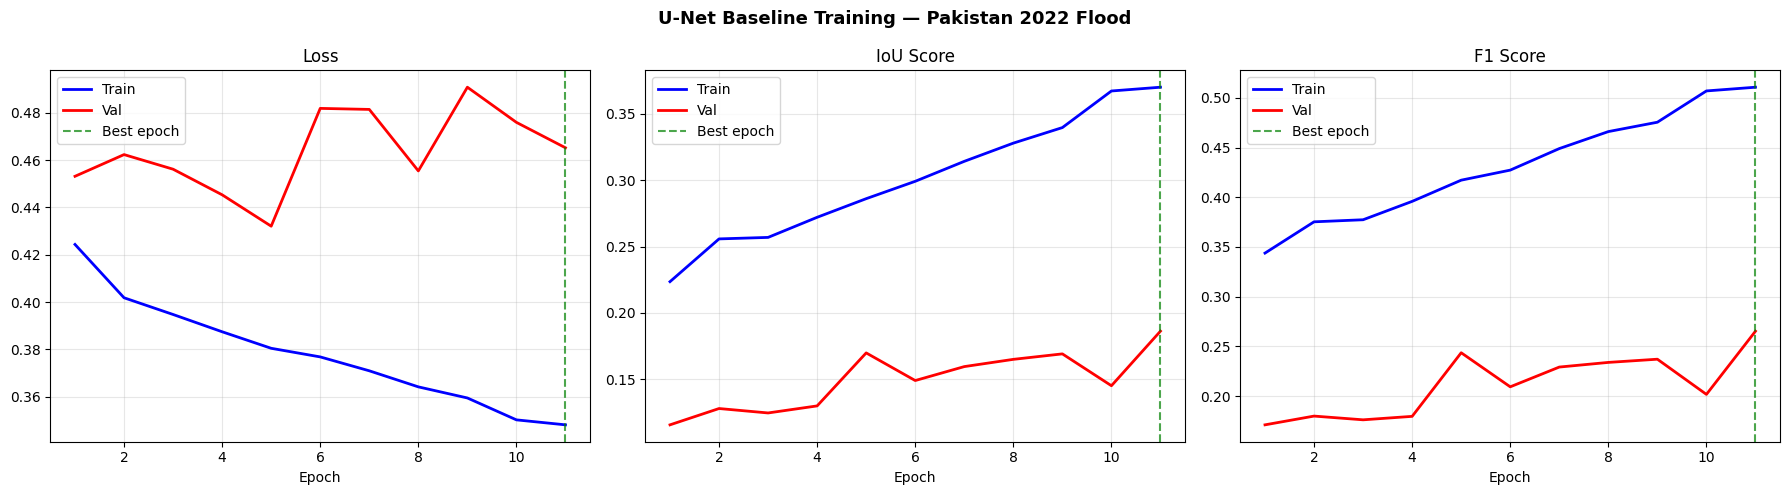

✓ Training curves saved

Loading best model (epoch 11)...
  Loaded from epoch : 11
  Best Val IoU      : 0.1863

Evaluating on test set...

  U-Net Baseline — Final Test Results
  IoU       : 0.2766
  F1        : 0.3388
  Precision : 0.3974
  Recall    : 0.3405

  ← These go in paper Table 1 row 1
  ← Notebook 06 will beat these numbers

✓ Results saved


In [5]:
# ============================================================
# Cell 5 — Evaluate on test set + plot results
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ── Plot training curves ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'U-Net Baseline Training — Pakistan 2022 Flood',
    fontsize=13, fontweight='bold')

epochs = range(1, len(history['train_loss'])+1)

axes[0].plot(epochs, history['train_loss'],
             'b-', label='Train', linewidth=2)
axes[0].plot(epochs, history['val_loss'],
             'r-', label='Val', linewidth=2)
axes[0].axvline(x=11, color='g', linestyle='--',
                alpha=0.7, label='Best epoch')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_iou'],
             'b-', label='Train', linewidth=2)
axes[1].plot(epochs, history['val_iou'],
             'r-', label='Val', linewidth=2)
axes[1].axvline(x=11, color='g', linestyle='--',
                alpha=0.7, label='Best epoch')
axes[1].set_title('IoU Score')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['train_f1'],
             'b-', label='Train', linewidth=2)
axes[2].plot(epochs, history['val_f1'],
             'r-', label='Val', linewidth=2)
axes[2].axvline(x=11, color='g', linestyle='--',
                alpha=0.7, label='Best epoch')
axes[2].set_title('F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/baseline_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Training curves saved")

# ── Load best model ───────────────────────────────────────
print("\nLoading best model (epoch 11)...")
checkpoint = torch.load(best_model_path,
                        map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"  Loaded from epoch : {checkpoint['epoch']}")
print(f"  Best Val IoU      : "
      f"{checkpoint['val_iou']:.4f}")

# ── Test set evaluation ───────────────────────────────────
print("\nEvaluating on test set...")
model.eval()
test_metrics = {'iou':0, 'f1':0,
                'precision':0, 'recall':0}
n_batches = 0

with torch.no_grad():
    for X, y in test_loader:
        X    = X.to(device)
        y    = y.to(device)
        pred = model(X)
        m    = compute_metrics(pred, y)
        for k in test_metrics:
            test_metrics[k] += m[k]
        n_batches += 1
        del X, y, pred

torch.cuda.empty_cache()
gc.collect()

# Average metrics
test_metrics = {k: v/n_batches
                for k, v in test_metrics.items()}

print(f"\n{'='*50}")
print(f"  U-Net Baseline — Final Test Results")
print(f"{'='*50}")
print(f"  IoU       : {test_metrics['iou']:.4f}")
print(f"  F1        : {test_metrics['f1']:.4f}")
print(f"  Precision : {test_metrics['precision']:.4f}")
print(f"  Recall    : {test_metrics['recall']:.4f}")
print(f"\n  ← These go in paper Table 1 row 1")
print(f"  ← Notebook 06 will beat these numbers")

# Save results
np.save(f'{OUTPUT_FOLDER}/baseline_results.npy',
        test_metrics)
print(f"\n✓ Results saved")

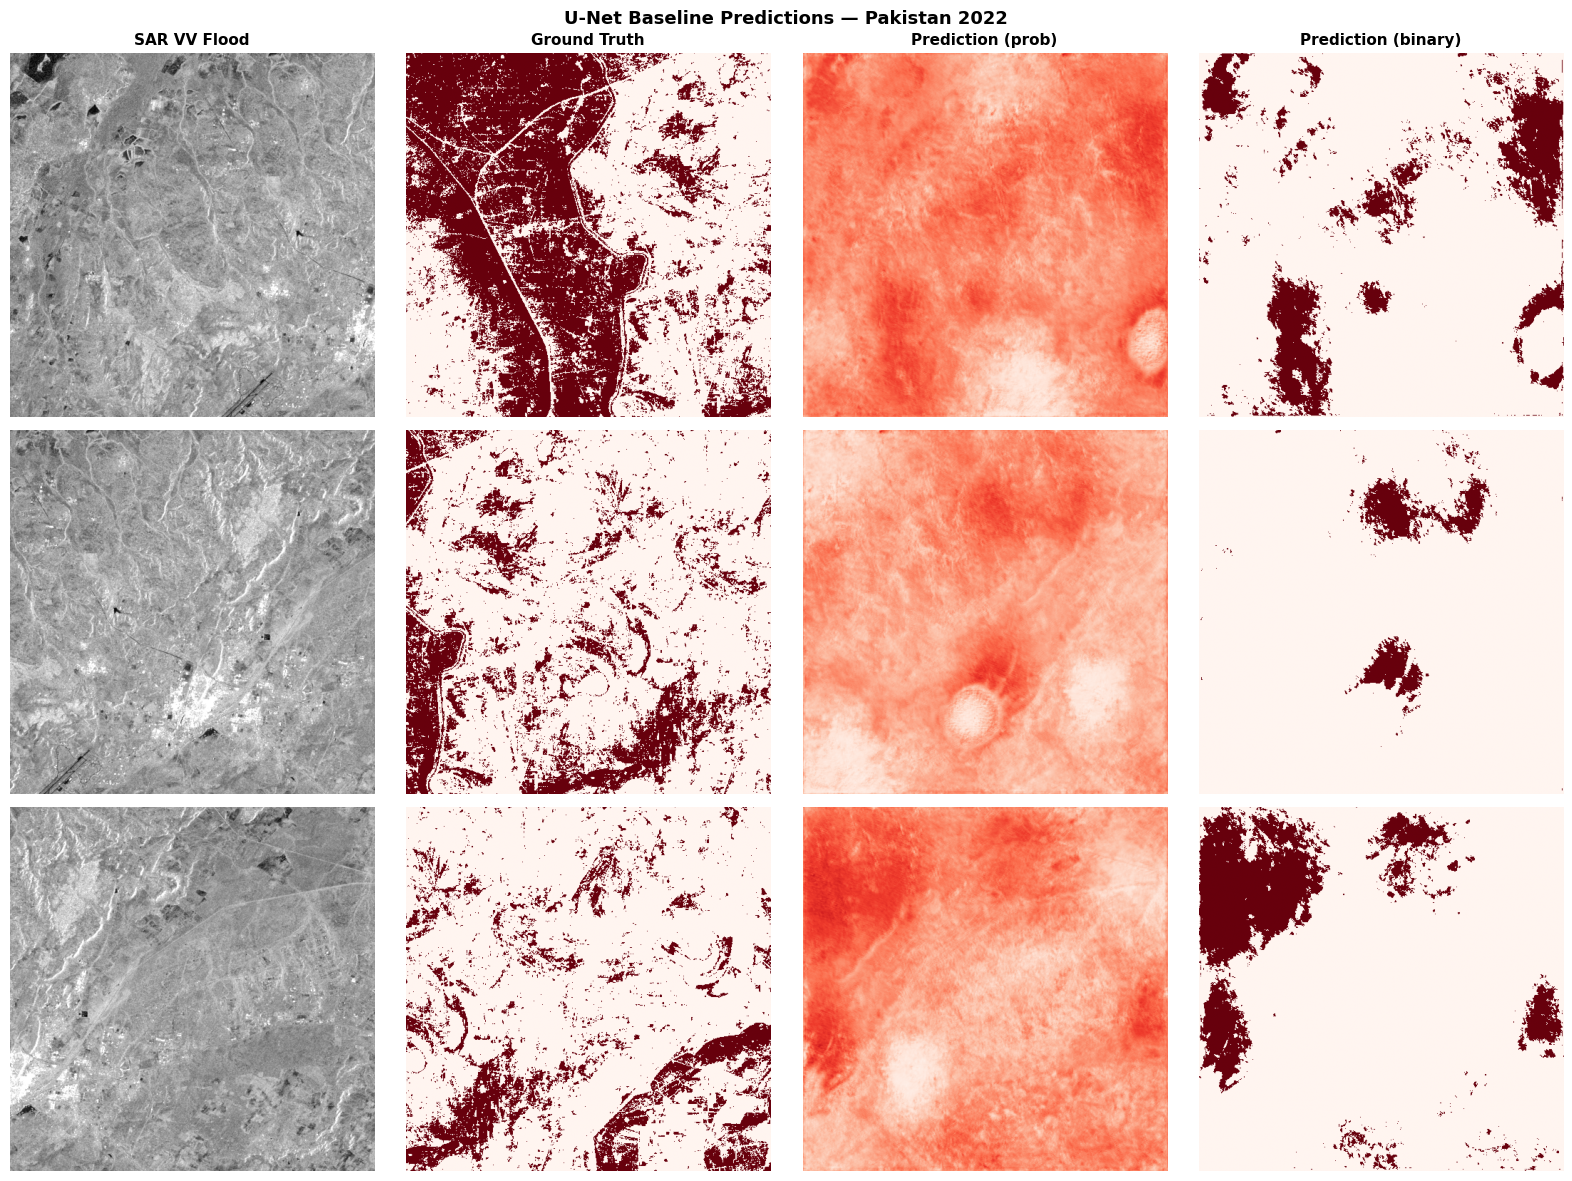

✓ Predictions saved

  Notebook 05 Complete!

  Baseline results saved to:
  /content/drive/MyDrive/FloodPINN_Models/baseline_results.npy
  /content/drive/MyDrive/FloodPINN_Models/baseline_curves.png
  /content/drive/MyDrive/FloodPINN_Models/baseline_predictions.png

  Next: 06_physics_uncertainty.ipynb
  → Add physics-guided loss function
  → Add MC Dropout uncertainty
  → Beat IoU: 0.2766


In [6]:
# ============================================================
# Cell 6 — Visualise sample predictions
# ============================================================

model.eval()
X_batch, y_batch = next(iter(test_loader))

with torch.no_grad():
    pred_batch = torch.sigmoid(
        model(X_batch.to(device))).cpu()

pred_binary = (pred_batch > 0.5).float()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle(
    'U-Net Baseline Predictions — Pakistan 2022',
    fontsize=13, fontweight='bold')

titles = ['SAR VV Flood', 'Ground Truth',
          'Prediction (prob)', 'Prediction (binary)']
for col, title in enumerate(titles):
    axes[0, col].set_title(
        title, fontsize=11, fontweight='bold')

for row in range(3):
    # SAR VV during flood
    axes[row,0].imshow(
        X_batch[row,2].numpy(), cmap='gray')
    axes[row,0].axis('off')

    # Ground truth label
    axes[row,1].imshow(
        y_batch[row,0].numpy(),
        cmap='Reds', vmin=0, vmax=1)
    axes[row,1].axis('off')

    # Prediction probability map
    axes[row,2].imshow(
        pred_batch[row,0].numpy(),
        cmap='Reds', vmin=0, vmax=1)
    axes[row,2].axis('off')

    # Binary prediction
    axes[row,3].imshow(
        pred_binary[row,0].numpy(),
        cmap='Reds', vmin=0, vmax=1)
    axes[row,3].axis('off')

plt.tight_layout()
plt.savefig(
    f'{OUTPUT_FOLDER}/baseline_predictions.png',
    dpi=150, bbox_inches='tight')
plt.show()

del X_batch, y_batch, pred_batch, pred_binary
torch.cuda.empty_cache()
gc.collect()

print("✓ Predictions saved")
print(f"\n{'='*50}")
print("  Notebook 05 Complete!")
print(f"{'='*50}")
print(f"\n  Baseline results saved to:")
print(f"  {OUTPUT_FOLDER}/baseline_results.npy")
print(f"  {OUTPUT_FOLDER}/baseline_curves.png")
print(f"  {OUTPUT_FOLDER}/baseline_predictions.png")
print(f"\n  Next: 06_physics_uncertainty.ipynb")
print(f"  → Add physics-guided loss function")
print(f"  → Add MC Dropout uncertainty")
print(f"  → Beat IoU: {test_metrics['iou']:.4f}")

In [7]:
# ============================================================
# Cell 7 — Save notebook to GitHub
# ============================================================
# File → Save a copy in GitHub
# Repo  : newazkhn/FloodPINN
# Path  : notebooks/05_unet_baseline.ipynb
# Commit: Add notebook 05: U-Net baseline training results
# ============================================================

print("Save this notebook to GitHub:")
print("  File → Save a copy in GitHub")
print("  Repo   : newazkhn/FloodPINN")
print("  Path   : notebooks/05_unet_baseline.ipynb")
print("  Commit : Add notebook 05: baseline results")
print(f"\n  Best Val IoU : {best_val_iou:.4f}")
print(f"  Test IoU     : {test_metrics['iou']:.4f}")
print(f"  Test F1      : {test_metrics['f1']:.4f}")

Save this notebook to GitHub:
  File → Save a copy in GitHub
  Repo   : newazkhn/FloodPINN
  Path   : notebooks/05_unet_baseline.ipynb
  Commit : Add notebook 05: baseline results

  Best Val IoU : 0.1863
  Test IoU     : 0.2766
  Test F1      : 0.3388
